## Setup

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from pyfonts import load_google_font
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np

## Prepare data

In [49]:
#Load data
df = pd.read_csv("scottish_munros.csv")

#filter for only currently active munros
print(len(df))
df = df[df["2021"]=="Munro"].reset_index(drop=True)
print(len(df))

#print dataframe
df.head()

604
282


,DoBIH_number,Name,Height_m,Height_ft,xcoord,ycoord,1891,1921,1933,1953,1969,1974,1981,1984,1990,1997,2021,Comments
0,1,Ben Chonzie,931.0,3054.0,277324.0,730857.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
1,17,Ben Vorlich,985.3,3233.0,262912.0,718916.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
2,18,Stuc a' Chroin,973.0,3192.0,261746.0,717465.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
3,32,Ben Lomond,973.7,3195.0,236707.0,702863.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN
4,26,Ben More,1174.0,3852.0,243276.0,724417.0,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,Munro,NaN


In [50]:

nevis_y = df[df["DoBIH_number"]=="278"]["ycoord"]
nevis_x = df[df["DoBIH_number"]=="278"]["xcoord"]

#calculate bearing from each munro to Ben Nevis/id=278 (highest mountain)
def cartesian_bearing(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    angle_rad = math.atan2(dx, dy)
    bearing_deg = (math.degrees(angle_rad) + 360) % 360
    return bearing_deg
bearings = []
for i in range(len(df)):
    bearing = cartesian_bearing(nevis_x, nevis_y, df.iloc[i]["xcoord"], df.iloc[i]["ycoord"])
    bearings.append(bearing)
df["bearing"] = bearings

#calculate distance from each munro to Ben Nevis/id=278 (highest mountain)
def euclidean_distance(x1, y1, x2, y2):
    return math.hypot(x2 - x1, y2 - y1)
distances = []
for i in range(len(df)):
    distance_m = euclidean_distance(nevis_x, nevis_y, df.iloc[i]["xcoord"], df.iloc[i]["ycoord"])
    distances.append(distance_m)
df["distance"] = distances

In [51]:
#round height to nearest 10m
df["Height_m_round"] = [round(i, -1) for i in df["Height_m"]]
df["radius"] = [abs(1340 - i) for i in df["Height_m_round"] ]

#round height to nearest 20m
df["Height_m_round_20"] = [round(i /20) *20 for i in df["Height_m"]]
df["radius_20"] = [abs(1340 - i) for i in df["Height_m_round_20"] ]

In [52]:
#calculate how many times defined as munro or munro top
df["munro_times"] = df[['1891', '1921', '1933', '1953', '1969', '1974', '1981', '1984', '1990',
       '1997', '2021']].apply(lambda row: ((row == "Munro")  | (row == "Munro Top")).sum(), axis=1).astype(float)

#calculate how many times defined as munro
df["munro_times"] = df[['1891', '1921', '1933', '1953', '1969', '1974', '1981', '1984', '1990',
       '1997', '2021']].apply(lambda row: ((row == "Munro")).sum(), axis=1).astype(float)

## Visualise

In [96]:
fontb = load_google_font("Roboto", weight="bold")
fontr = load_google_font("Roboto", weight="regular") 
fontsb = load_google_font("Roboto", weight="semi-bold") 
cmap = mpl.colormaps['YlGnBu_r']

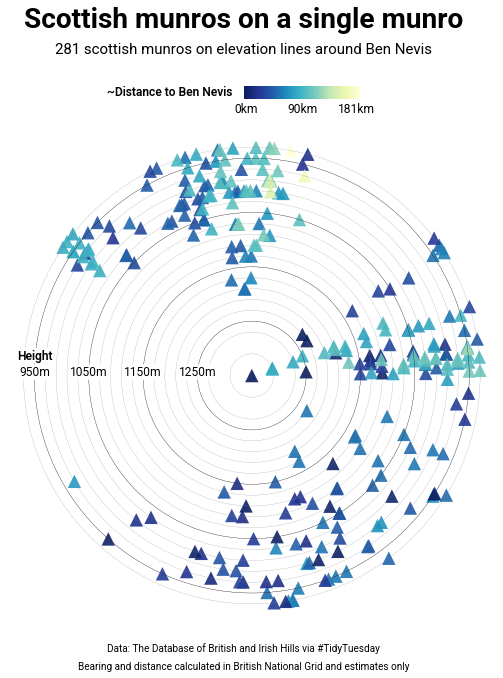

In [100]:
#reduce column list
df_plot = df[['DoBIH_number', 'Name', 'Height_m', 'Height_m_round_20', 'radius_20', 'bearing', 'munro_times', 'distance']].copy()

#calculate coordinates to plot
df_plot["angle_rad"] = [math.radians(90 - i) for i in df_plot["bearing"]]
df_plot["xplot"] = df_plot["radius_20"] * np.cos(df_plot["angle_rad"])
df_plot["yplot"] = df_plot["radius_20"] * np.sin(df_plot["angle_rad"])

#plot ------------------------------------------------
fig, ax = plt.subplots(figsize =(9,9))

#plot munros
ax.scatter(df_plot["xplot"], df_plot["yplot"],
           #s=df_plot["munro_times"]*12,  
           s=180,
           marker="^",
           alpha=0.9,
           c=df_plot["distance"],    
           cmap=cmap,              
           edgecolors='none')       

#draw radius (=height elevation line)
for radius in df_plot["radius_20"].unique():
    circle = plt.Circle((0, 0), radius, fill=False, edgecolor="grey", linestyle='solid', linewidth=0.2)
    ax.add_patch(circle)

#add elevation lines with labels
label_angle_rad = math.radians(90 - 270)
for i, radius in enumerate([100,200,300,400]):
    circle = plt.Circle((0, 0), radius, fill=False, edgecolor="black",linestyle='solid', linewidth=0.25)
    ax.add_patch(circle)  
    plt.text(x=radius * np.cos(label_angle_rad),
         y=radius * np.sin(label_angle_rad),
         s=str(1350-radius)+"m",
         ha="center",
         font=fontr,
         fontsize=12,
         bbox=dict(
            facecolor="white",
            edgecolor="None",
            boxstyle="round,pad=0.1"))
#legend title
plt.text(x=400 * np.cos(label_angle_rad),
         y=400 * np.sin(label_angle_rad)+30,
         s="Height",
         ha="center",
         font=fontsb,
         fontsize=12,
         bbox=dict(
            facecolor="white",
            edgecolor="None",
            boxstyle="round,pad=0.1"))

# colorbar ------------------
cbaxes = fig.add_axes([0.5, 0.93, 0.18, 0.02]) #axes to hold colorbar
cmappable = cm.ScalarMappable(norm=mpl.colors.Normalize(0,1), cmap=cmap)              
cb = plt.colorbar(cmappable, cax=cbaxes, anchor=(1,1.2), orientation='horizontal', 
                  drawedges=False, ticks=[0.02, 0.5,0.97])
cb.ax.tick_params(length=0)
cb.ax.set_xticklabels(["0km", "90km", "181km"], fontproperties=fontr, fontsize=12)
cb.outline.set_visible(False)
cbaxes.text(-0.1,0.5,"~Distance to Ben Nevis", font=fontsb, fontsize=12, ha="right", va="center")

#style axis -----------------------
ax.axis("off")
ax.set_aspect('equal')
maxradius = 450
ax.set_xlim(- maxradius, maxradius)
ax.set_ylim(-maxradius, maxradius)

#title and footer -----------------------
fig.text(x=0.5, y=1.04, s="Scottish munros on a single munro", 
         size=28, ha="center", font=fontb)
fig.text(x=0.5, y=1, s="281 scottish munros on elevation lines around Ben Nevis", 
         size=15, ha="center", font=fontr)
fig.text(x=0.5, y=0.05, s="Data: The Database of British and Irish Hills via #TidyTuesday\nBearing and distance calculated in British National Grid and estimates only", 
         size=10, ha="center", font=fontr, linespacing=2)

#save output
plt.savefig('scottish-munros.png', bbox_inches='tight', pad_inches=1, facecolor="white", dpi=120)
plt.savefig('scottish-munros.svg')

plt.show()

## Playground

In [56]:
df.sort_values(by="Height_m", ascending=False)

,DoBIH_number,Name,Height_m,Height_ft,xcoord,ycoord,1891,1921,1933,1953,...,1997,2021,Comments,bearing,distance,Height_m_round,radius,Height_m_round_20,radius_20,munro_times
72,278,Ben Nevis,1344.53,4411.0,216666.0,771288.0,Munro,Munro,Munro,Munro,...,Munro,Munro,NaN,0.000000,0.000000,1340.0,0.0,1340,0,11.0
151,518,Ben Macdui [Beinn Macduibh],1309.00,4295.0,298899.0,798943.0,Munro,Munro,Munro,Munro,...,Munro,Munro,1891-1953: Ben Macdhui,71.412181,86758.661320,1310.0,30.0,1300,40,11.0
144,519,Braeriach,1296.00,4252.0,295328.0,799916.0,Munro,Munro,Munro,Munro,...,Munro,Munro,NaN,70.001689,83709.453636,1300.0,40.0,1300,40,11.0
146,521,Cairn Toul,1291.00,4236.0,296328.0,797229.0,Munro,Munro,Munro,Munro,...,Munro,Munro,NaN,71.962765,83779.291743,1290.0,50.0,1300,40,11.0
145,523,Sgor an Lochain Uaine,1258.00,4127.0,295422.0,797693.0,Munro,Munro Top,Munro Top,Munro Top,...,Munro,Munro,"1891: Sgor an Lochain Uaine, Carn Toul; 1921-1...",71.464931,83064.622801,1260.0,80.0,1260,80,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,759,Meall na Teanga,916.80,3008.0,222023.0,792471.0,Munro Top,Munro,Munro,Munro,...,Munro,Munro,1891: Meall an Teanga,14.192061,21849.872723,920.0,420.0,920,420,10.0
14,75,Beinn a' Chleibh,916.30,3006.0,225054.0,725606.0,Munro,Munro,Munro,Munro,...,Munro,Munro,NaN,169.595409,46445.706669,920.0,420.0,920,420,11.0
17,76,Ben Vane,915.76,3004.0,227753.0,709844.0,Munro,Munro,Munro,Munro,...,Munro,Munro,NaN,169.771569,62436.261139,920.0,420.0,920,420,11.0
127,438,Carn Aosda,915.30,3003.0,313397.0,779164.0,Munro,Munro,Munro,Munro,...,Munro,Munro,NaN,85.345150,97051.108891,920.0,420.0,920,420,11.0


In [57]:
df["Height_m"].describe()

count     282.000000
mean     1017.870887
std        83.746672
min       914.600000
25%       953.000000
50%       998.900000
75%      1063.625000
max      1344.530000
Name: Height_m, dtype: float64

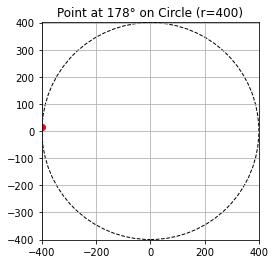

In [58]:
radius = 400
bearing = 178

# Convert to radians
angle_rad = np.radians(bearing)

# Calculate coordinates
x = radius * np.cos(angle_rad)
y = radius * np.sin(angle_rad)

# Plot
fig, ax = plt.subplots()
ax.plot(x, y, 'ro')  # red dot
ax.set_aspect('equal')
ax.set_xlim(-radius - 1, radius + 1)
ax.set_ylim(-radius - 1, radius + 1)

# Optional: draw the circle for context
circle = plt.Circle((0, 0), radius, fill=False, linestyle='--')
ax.add_patch(circle)

plt.title(f"Point at {bearing}° on Circle (r={radius})")
plt.grid(True)
plt.show()
